In [176]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [177]:
df=pd.read_csv('Causas_de_mortalidad_2020_20260416.csv')

In [178]:
df.head()

,Causas de mortalidad,Género,Edad
0,INFARTO AGUDO DEL MIOCARDIO,MASCULINO,83.0
1,HIPOGLICEMIA SEVERA,MASCULINO,67.0
2,TUMOR MALIGNO DE ESOFAGO,MASCULINO,80.0
3,SINDROME ANEMICO,FEMENINO,52.0
4,INFARTO AGUDO A MIOCARDIO,FEMENINO,75.0


In [179]:
df.isna().sum()

Causas de mortalidad    0
Género                  0
Edad                    1
dtype: int64

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Causas de mortalidad  314 non-null    object 
 1   Género                314 non-null    object 
 2   Edad                  313 non-null    float64
dtypes: float64(1), object(2)
memory usage: 7.5+ KB


In [181]:
df['Edad']=df['Edad'].astype('Int64')

In [182]:
df[df.isna().any(axis=1)]

,Causas de mortalidad,Género,Edad
221,HIPOXIA FETAL,FEMENINO,<NA>


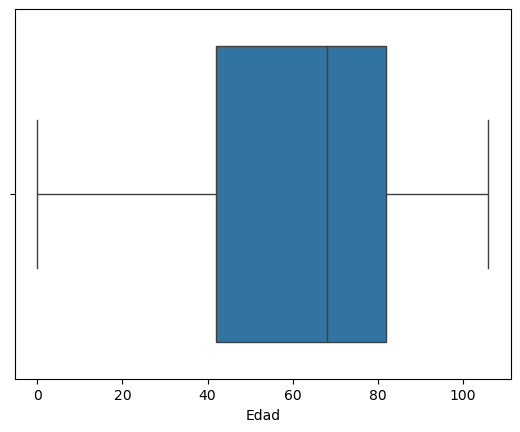

In [183]:
sns.boxplot(x=df['Edad'])
plt.show()

In [184]:
Q1 = df['Edad'].quantile(0.25)
Q3 = df['Edad'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['Edad'] < limite_inferior) | (df['Edad'] > limite_superior)]
outliers


,Causas de mortalidad,Género,Edad


In [185]:
df['Edad']= df['Edad'].fillna(round(df['Edad'].mean()))

In [186]:
df['Género']=df['Género'].replace({'MASCULINO':'M','FEMENINO':'F'})

In [187]:
df['Género']=df['Género'].astype('category')

In [188]:
df['Edad'].describe()

count        314.0
mean     62.082803
std      24.718986
min            0.0
25%          42.25
50%           68.0
75%           82.0
max          106.0
Name: Edad, dtype: Float64

In [189]:
df['Causas de mortalidad'] = df['Causas de mortalidad'].str.lower().str.strip()

In [190]:
df['Causas de mortalidad'].unique()

array(['infarto agudo del miocardio', 'hipoglicemia severa',
       'tumor maligno de esofago', 'sindrome anemico',
       'infarto agudo a miocardio', 'infarto agudo de miocardio',
       'encefalopatia hipoxica', 'hipoxia generalizada',
       'ifarto agudode miocardio', 'laceración femoral derecha',
       'hemorragia masiva', 'laceracion encefalica- laceracion pulmonar',
       'laceracion encefalica', 'laceracion encefalica severa',
       'neumonia bacteriana', 'infartoagudo de miocardio',
       'falla respiratoria', 'iinfarto agudo del miocardio',
       'hipovolemia aguda', 'laceracion cerebral hemorragica',
       'muerte cerebral', 'hipoxia', 'falla ventilatoria',
       'infarto aguda de miocardio', 'infarto agudod e miocardio',
       'laceración de tallo cerebral', 'insuficiencia respiratoria',
       'encefalopatia hipoxica isquemica', 'hipetension endocraneana',
       'trauma raquimedular cervical', 'laceración cerebral',
       'falla multisistemica', 'hipoxia cerebra

In [191]:
import re
import unicodedata

def limpiar_texto(texto):
    texto = texto.lower().strip()
    

    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    
   
    texto = re.sub(r'infarto.*miocardio', 'infarto agudo de miocardio', texto)
    texto = re.sub(r'paro cardio.*', 'paro cardiorespiratorio', texto)
    texto = re.sub(r'hipoxia.*', 'hipoxia', texto)
    texto = re.sub(r'anoxia.*', 'hipoxia', texto)
    texto = re.sub(r'falla ventila.*|falla respiratoria.*|insuficiencia respiratoria.*', 'falla respiratoria', texto)
    texto = re.sub(r'hemorragia.*digestiva.*', 'hemorragia digestiva', texto)
    texto = re.sub(r'hemorragia.*', 'hemorragia', texto)
    texto = re.sub(r'accidente cerebro.*', 'accidente cerebrovascular', texto)
    texto = re.sub(r'laceracion.*|contusion.*|trauma.*|politraumatismo.*', 'trauma', texto)
    texto = re.sub(r'sepsis.*|septicemia.*|septisemia.*', 'sepsis', texto)
    texto = re.sub(r'hipovolemia.*|choque.*', 'shock', texto)
    texto = re.sub(r'edema pulmonar.*', 'edema pulmonar', texto)
    texto = re.sub(r'trombo.*', 'tromboembolismo', texto)
    
    return texto

df['causa_limpia'] = df['Causas de mortalidad'].apply(limpiar_texto)

In [192]:
categorias = {
    'infarto agudo de miocardio': 'cardiovascular',
    'paro cardiorespiratorio': 'cardiovascular',
    'tromboembolismo': 'cardiovascular',

    'hipoxia': 'respiratorio',
    'falla respiratoria': 'respiratorio',
    'edema pulmonar': 'respiratorio',

    'shock': 'shock_hipovolemico',
    'hemorragia': 'shock_hipovolemico',

    'trauma': 'trauma',

    'sepsis': 'infeccioso',

    'accidente cerebrovascular': 'neurologico',

    'tumor maligno de esofago': 'oncologico',

    'hipoglicemia severa': 'metabolico',
    'hipoglucemia severa': 'metabolico',
    'anemia': 'metabolico',
}

In [193]:
df['categoria'] = df['causa_limpia'].map(categorias).fillna('otros')

In [194]:
print(df['categoria'].value_counts())
print(df['categoria'].value_counts(normalize=True) * 100)

categoria
cardiovascular        131
respiratorio           49
shock_hipovolemico     43
otros                  42
trauma                 32
metabolico              7
infeccioso              6
neurologico             3
oncologico              1
Name: count, dtype: int64
categoria
cardiovascular        41.719745
respiratorio          15.605096
shock_hipovolemico    13.694268
otros                 13.375796
trauma                10.191083
metabolico             2.229299
infeccioso             1.910828
neurologico            0.955414
oncologico             0.318471
Name: proportion, dtype: float64


In [195]:
df.columns=['causas_de_mortalidad', 'genero', 'edad','causa_limpia','categoria']

In [196]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
db = os.getenv("DB_NAME")

In [197]:
from sqlalchemy import create_engine
from sqlalchemy.exc import SQLAlchemyError
import logging


engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{db}"
)
# log de errores
logging.basicConfig(filename='etl_errores.log', level=logging.ERROR)

def cargar_dataframe(df, nombre_tabla):
    try:
        
        if df.empty:
            print(f" {nombre_tabla}: DataFrame vacío")
            return
        
        if df.isna().sum().sum() > 0:
            print(f" {nombre_tabla}: Hay valores nulos (se insertarán como NULL)")
        
       
        df.to_sql(
            nombre_tabla,
            con=engine,
            if_exists='append',
            index=False,
            chunksize=1000,   
            method='multi'   
        )
        
        print(f" {nombre_tabla}: Carga exitosa")
    
    except SQLAlchemyError as e:
        logging.error(f"{nombre_tabla} - SQL Error: {str(e)}")
        print(f" Error SQL en {nombre_tabla}")
    
    except Exception as e:
        logging.error(f"{nombre_tabla} - General Error: {str(e)}")
        print(f" Error general en {nombre_tabla}")

In [198]:
cargar_dataframe(df, 'fact_mortalidad')

 fact_mortalidad: Carga exitosa


In [199]:
top_mortalidad=df['causas_de_mortalidad'].value_counts().head(4)
top_mortalidad

causas_de_mortalidad
infarto agudo de miocardio          72
hemorragia masiva                   19
infarto agudo del miocardio         18
insuficiencia respiratoria aguda    12
Name: count, dtype: int64

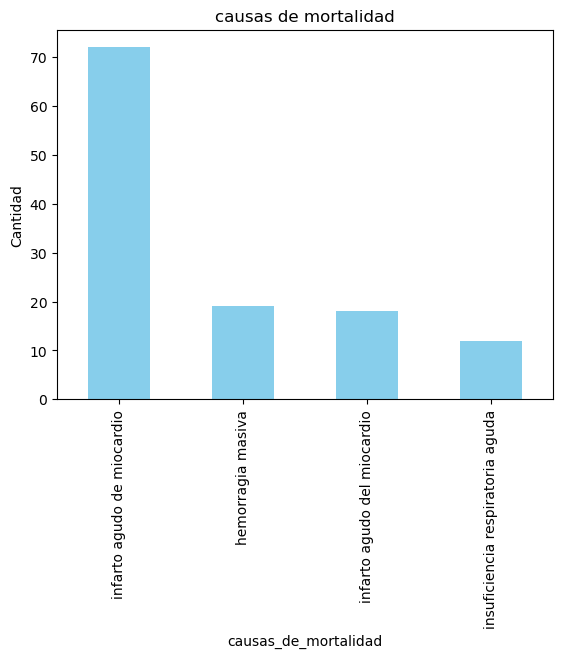

In [200]:
top_mortalidad.plot.bar(title="causas de mortalidad", ylabel="Cantidad", color="skyblue")
plt.show()